# Task 2: Yelp Polarity sentiment classification

Loads saved artifacts only (no training). The run is chosen with the CONFIG environment variable.

## 1. Setup and config

In [1]:
import os, sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import notebook_helpers as nh
cfg = nh.setup(os.environ.get("CONFIG", "local"))

run: gpu   config: gpu.yaml   seed: 42
device on this machine: cuda (NVIDIA GeForce RTX 4090)
models: ngram_bag, transformer, bigru


## 2. Data summary

In [2]:
nh.show_data_summary(cfg)

,split,reviews,negative,positive,OOV tokens %,empty after cleaning
0,train,504000,251808,252192,0.432,32
1,val,56000,28192,27808,0.494,5
2,test,38000,19000,19000,0.489,0


vocabulary size: 50000   cleaned mean tokens: {'train': 93.04, 'val': 92.98, 'test': 92.7}
rows dropped as invalid: {'train': {'not_a_string': 0, 'empty': 0, 'bad_label': 0}, 'test': {'not_a_string': 0, 'empty': 0, 'bad_label': 0}}
reviews with literal escape sequences: train 302,738, test 20,462


## 3. EDA figures and a cleaning example

**class_balance**

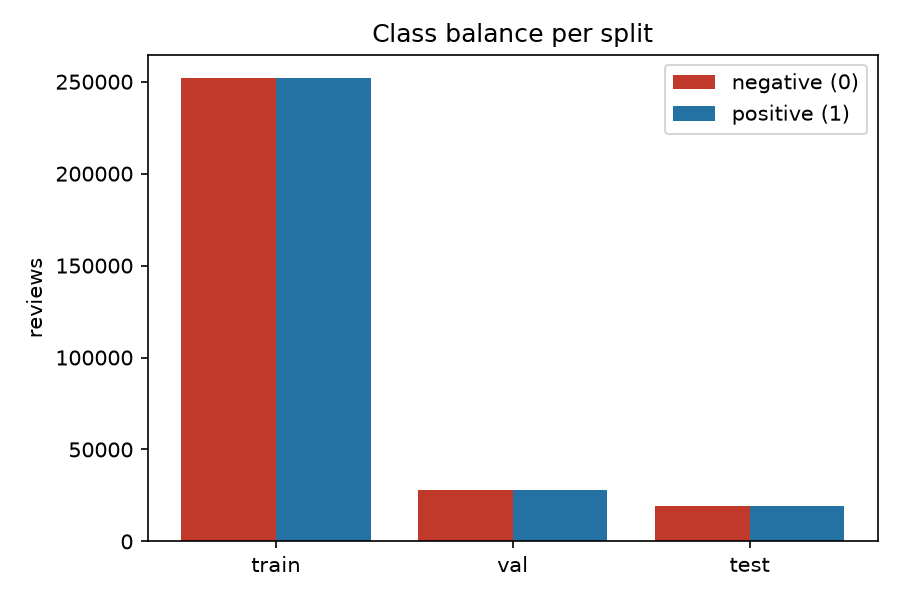

**length_raw_words**

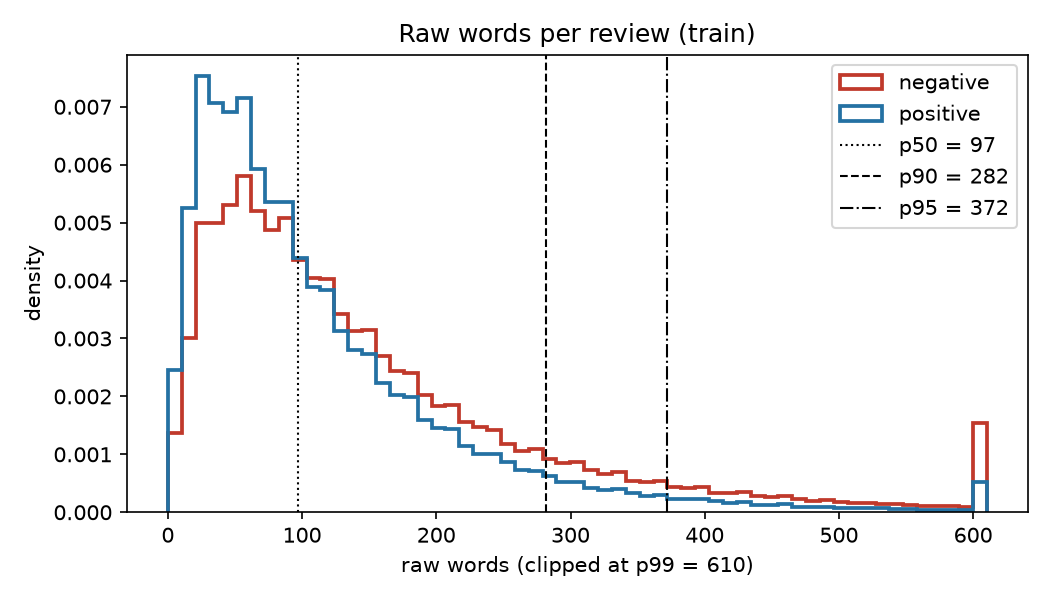

**length_tokens**

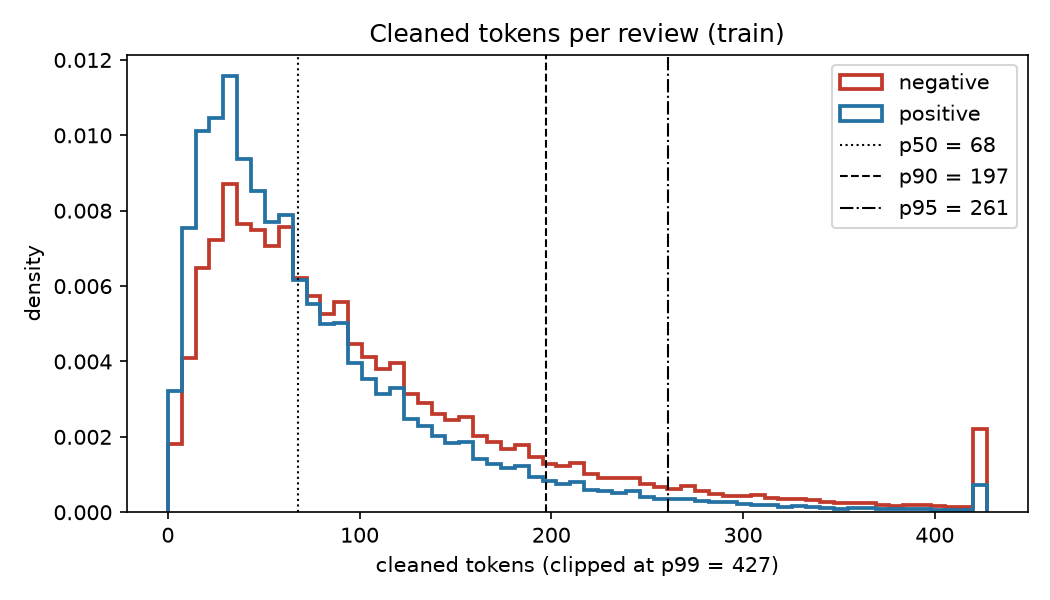

Before / after cleaning (first training review):
--- train review 0 (label 1) ---
RAW:     If you are a vegetarian.....you must try the veggie taco. The mountain of goodness atop the tasty fry bread will leave your belly too full, but your mouth will definitely want more. This is a great spot for a a mixed herbivore/carnivore lunch stop, as my non-veggie friends can't seem to get enough of the red or green chili tacos. I am much looking forward to returning to try the honey fry bread desert, as I have never had room for desert after the massive tacos!!!
CLEANED: if you vegetarian you must try veggie taco mountain goodness atop tasty fry bread will leave your belly too full but your mouth will definitely want more great spot mixed herbivore carnivore lunch stop my non veggie friend can not seem get enough red green chili taco i much looking forward returning try honey fry bread desert i never room desert after massive taco


In [3]:
nh.show_eda(cfg)

## 4. Model architectures

In [4]:
nh.show_architectures(cfg)

===== ngram_bag =====
NGramBag(
  (bag): EmbeddingBag(2050000, 32, mode='mean')
  (dropout): Dropout(p=0.4, inplace=False)
  (out): Linear(in_features=32, out_features=1, bias=True)
)
===== transformer =====
TransformerClassifier(
  (embed): Embedding(50000, 128, padding_idx=0)
  (pos_embed): Embedding(320, 128)
  (embed_dropout): Dropout(p=0.2, inplace=False)
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
        (dropout1): Dropout(

===== bigru =====
BiGRUClassifier(
  (word_embed): Embedding(50000, 128, padding_idx=0)
  (bigram_embed): Embedding(500001, 64, padding_idx=0)
  (emb_dropout): Dropout(p=0.25, inplace=False)
  (gru): GRU(192, 128, num_layers=2, batch_first=True, dropout=0.25, bidirectional=True)
  (attn_proj): Linear(in_features=256, out_features=128, bias=True)
  (attn_vector): Linear(in_features=128, out_features=1, bias=False)
  (head_dropout): Dropout(p=0.4, inplace=False)
  (out): Linear(in_features=768, out_features=1, bias=True)
)


,model,total,embeddings,other
0,ngram_bag,65600033,65600000,33
1,transformer,6838017,6440960,397057
2,bigru,38977601,38400064,577537


## 5. Training curves and training summary

**ngram_bag: loss curves**

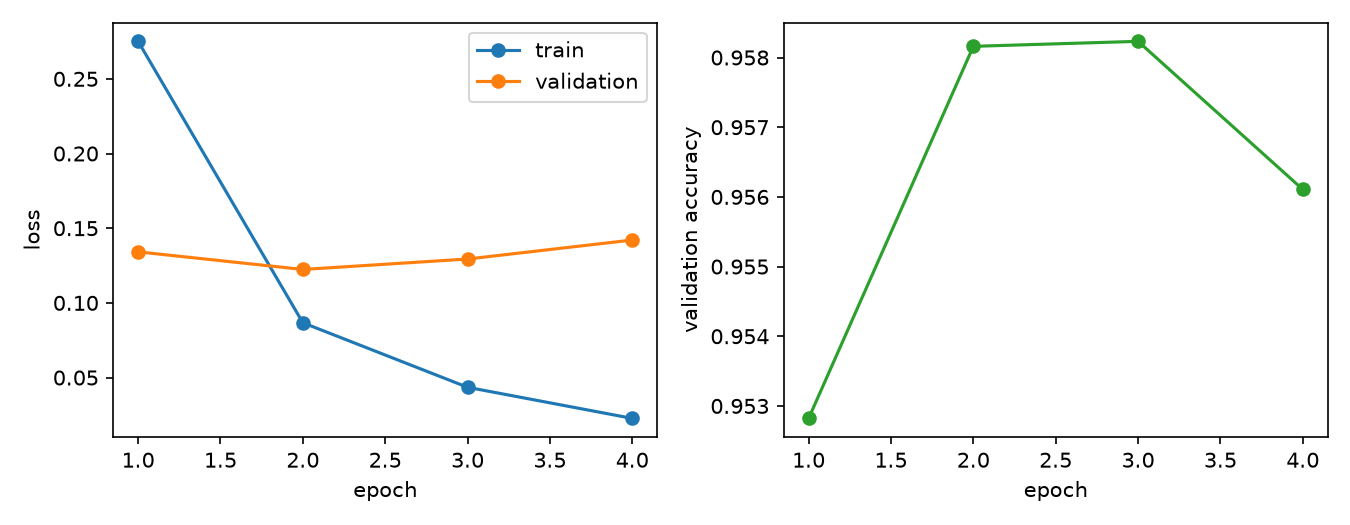

**transformer: loss curves**

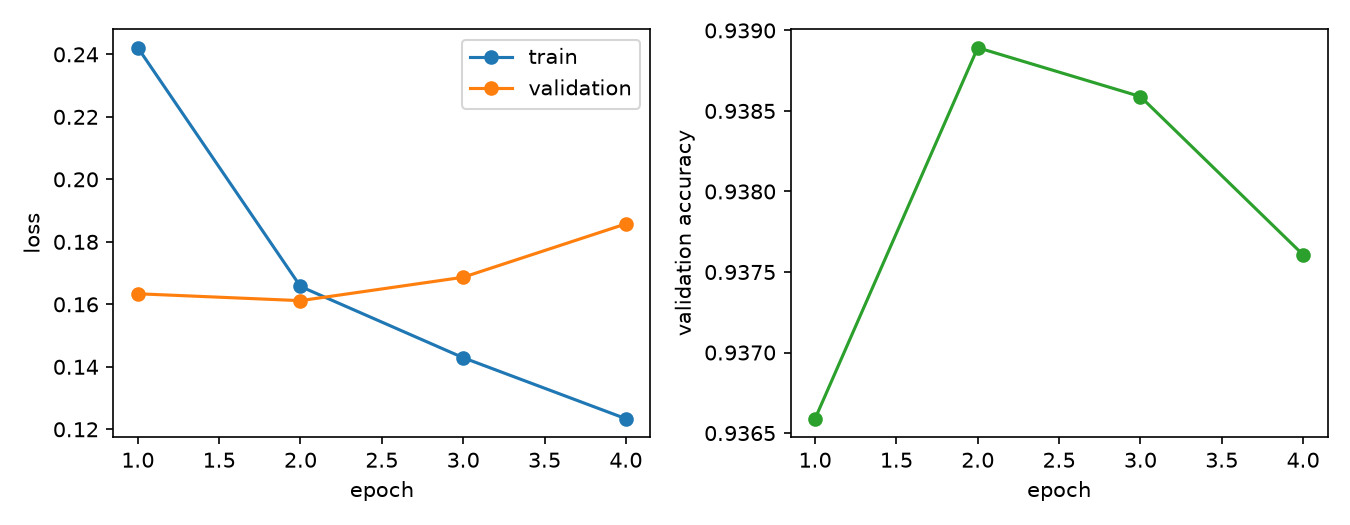

**bigru: loss curves**

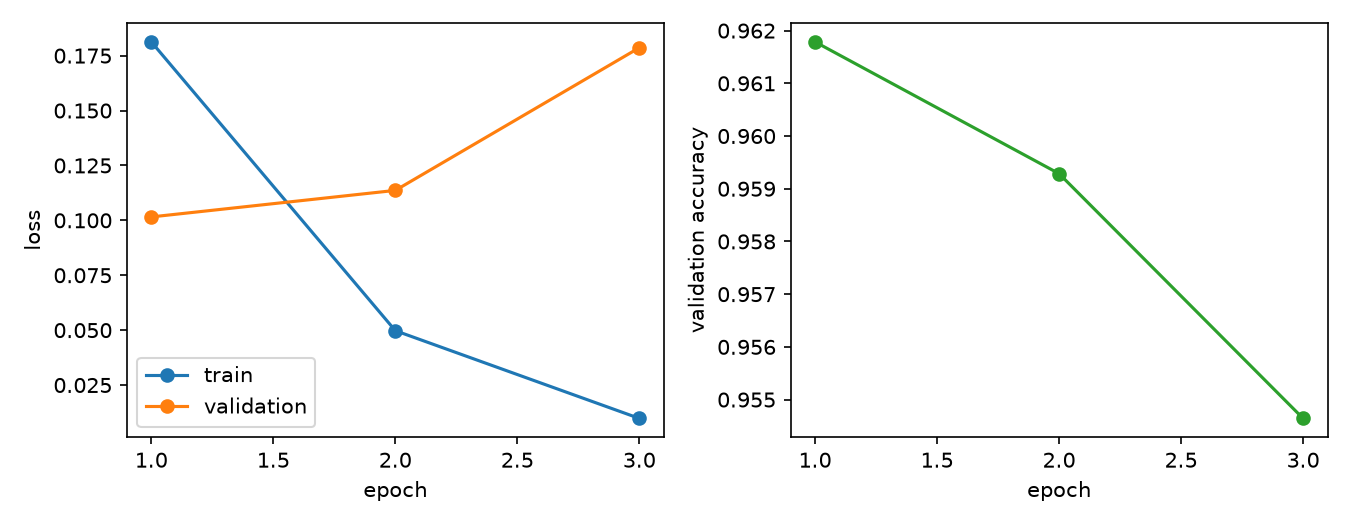

,model,epochs run,best epoch,best val loss,best val acc,train time (s),examples/s,peak memory (MB),device
0,ngram_bag,4,2,0.1224,0.9582,147,13791,2018,NVIDIA GeForce RTX 4090
1,transformer,4,2,0.1612,0.9389,121,16898,702,NVIDIA GeForce RTX 4090
2,bigru,3,1,0.1016,0.9618,311,4943,1490,NVIDIA GeForce RTX 4090


In [5]:
nh.show_training(cfg)

## 6. Test metrics and evaluation plots

| model | accuracy [95% CI] | macro-F1 [95% CI] | ROC-AUC | PR-AUC | MCC [95% CI] | Brier | ECE | McNemar p (vs baseline) | params | train time (s) | inference ex/s |
|---|---|---|---|---|---|---|---|---|---|---|---|
| ngram_bag | 0.9598 [0.9577, 0.9616] | 0.9598 [0.9577, 0.9616] | 0.9907 | 0.9906 | 0.9196 [0.9154, 0.9232] | 0.0314 | 0.0059 | baseline | 65,600,033 | 147 | 197676 |
| transformer | 0.9428 [0.9406, 0.9451] | 0.9428 [0.9406, 0.9451] | 0.9867 | 0.9872 | 0.8857 [0.8812, 0.8902] | 0.0431 | 0.0128 | 1.23e-58 (b=1134, c=491) | 6,838,017 | 121 | 63449 |
| bigru | 0.9624 [0.9604, 0.9643] | 0.9624 [0.9604, 0.9643] | 0.9940 | 0.9942 | 0.9248 [0.9208, 0.9285] | 0.0278 | 0.0030 | 0.00198 (b=473, c=574) | 38,977,601 | 311 | 31904 |


**roc_curves**

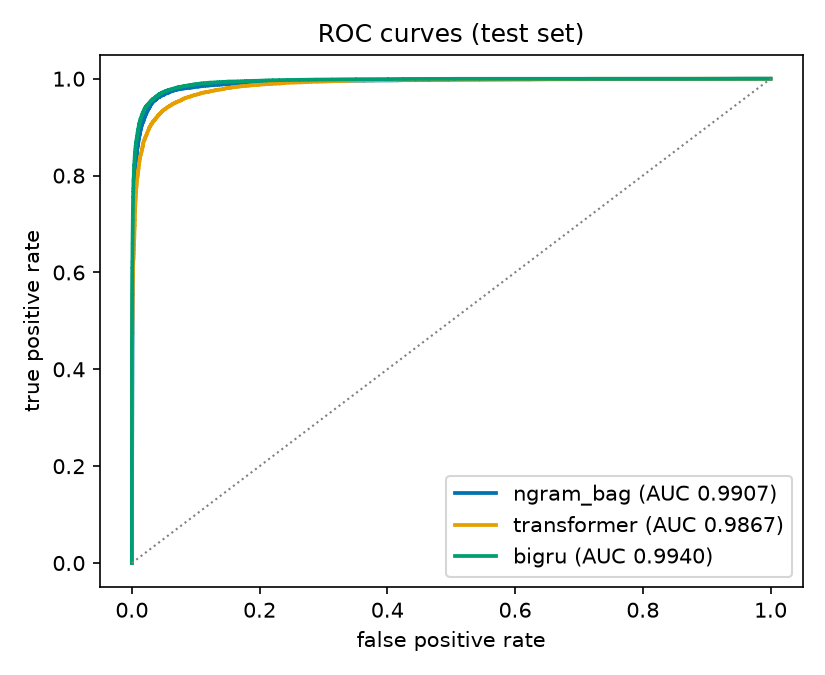

**pr_curves**

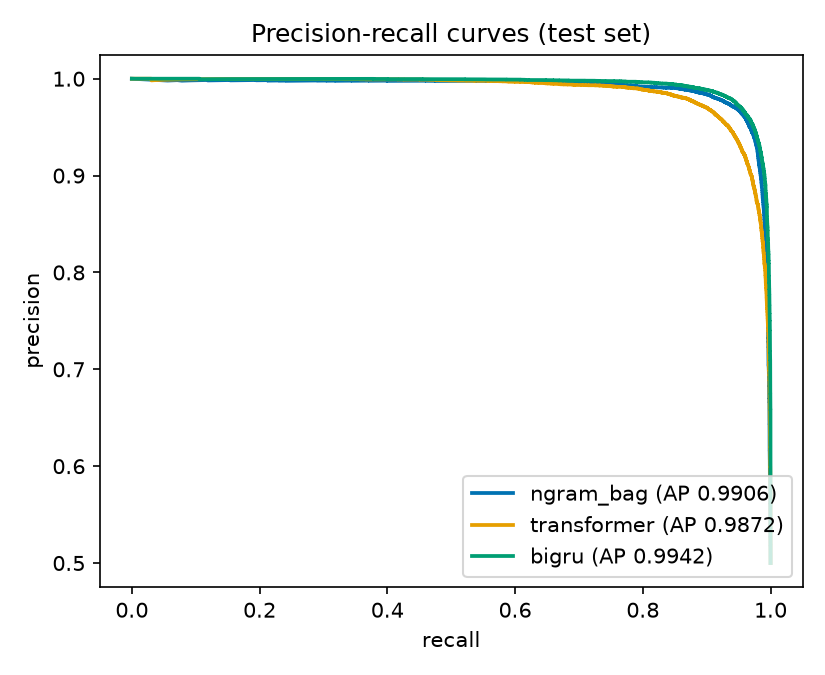

**reliability_diagrams**

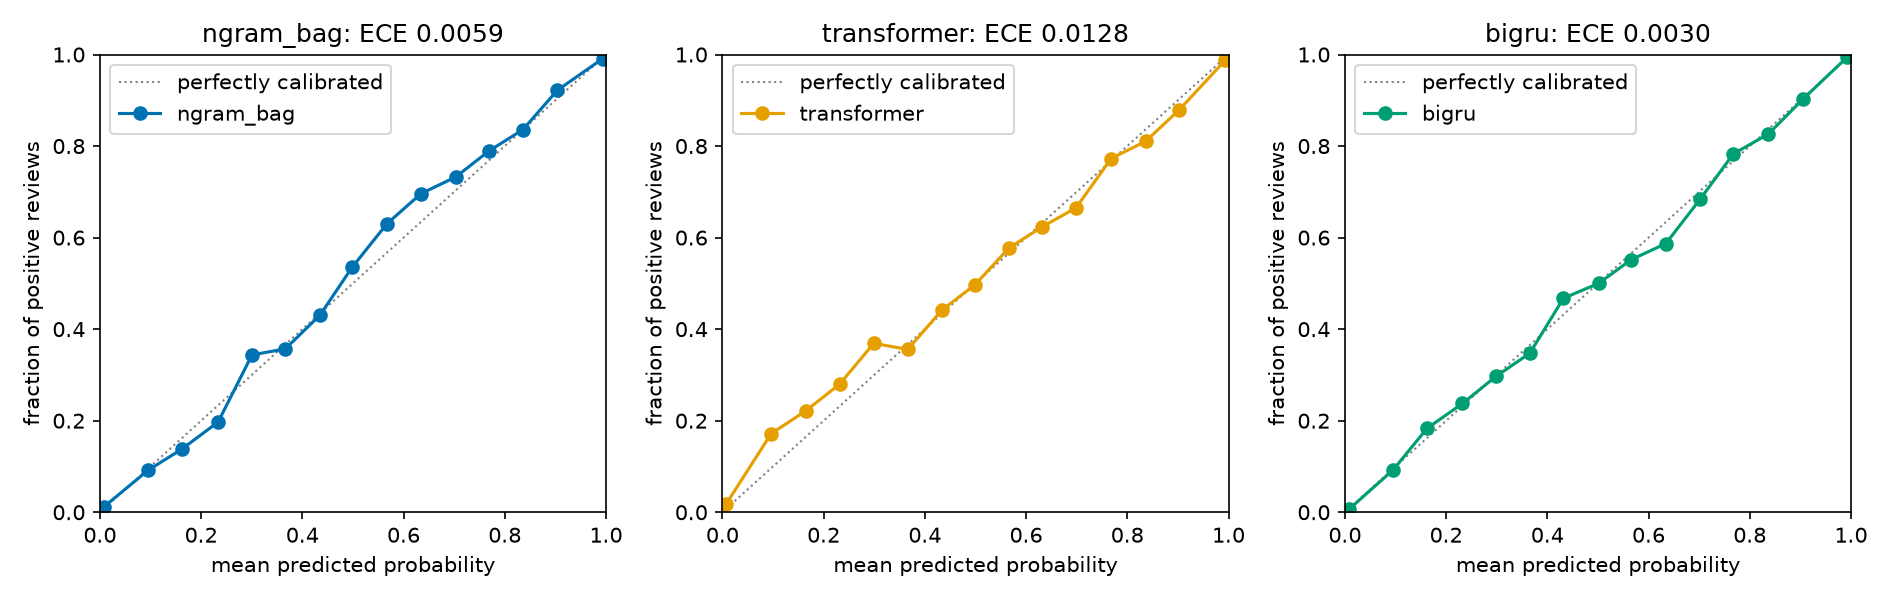

**macro_f1_bar**

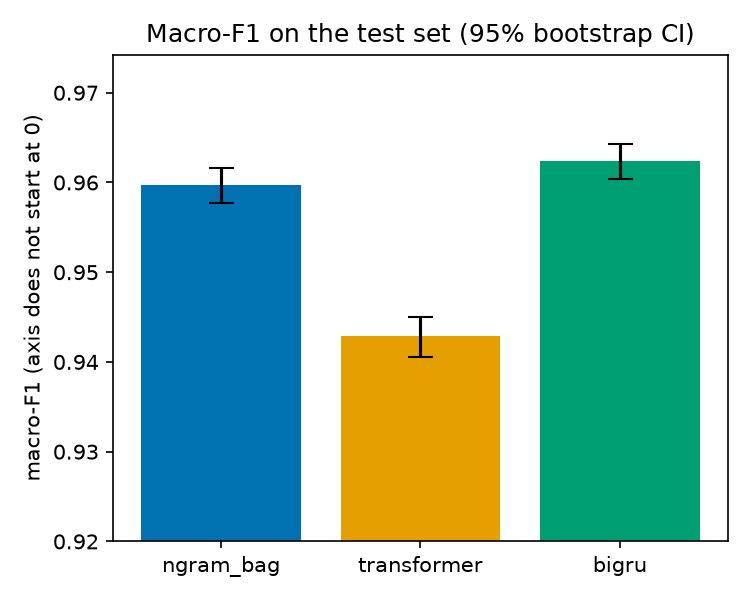

**loss_curves_overlay**

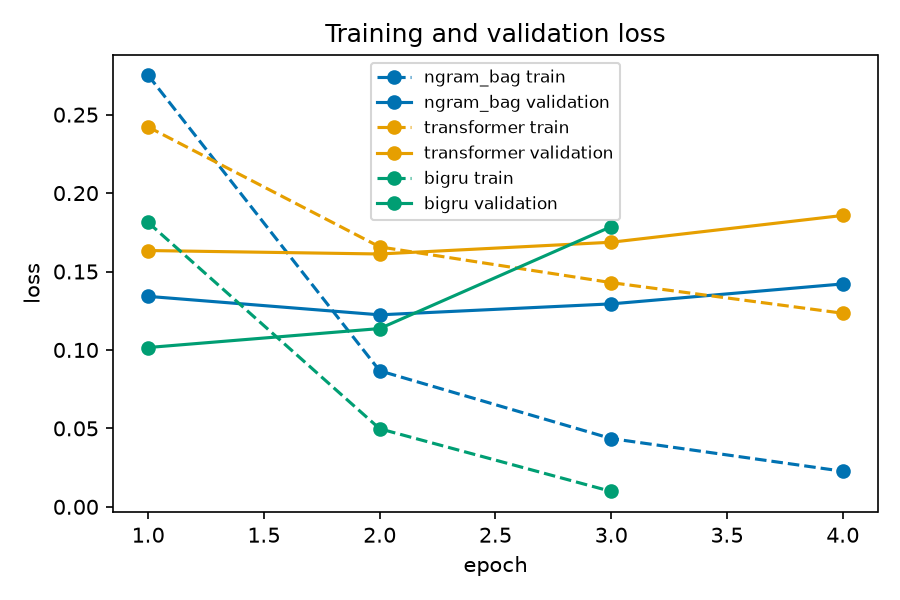

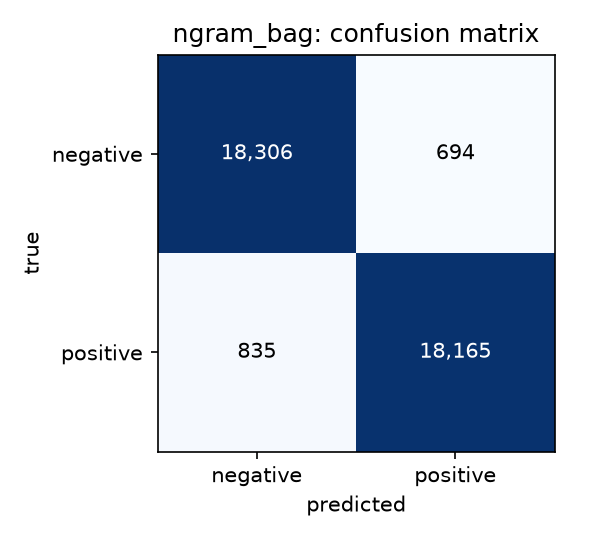

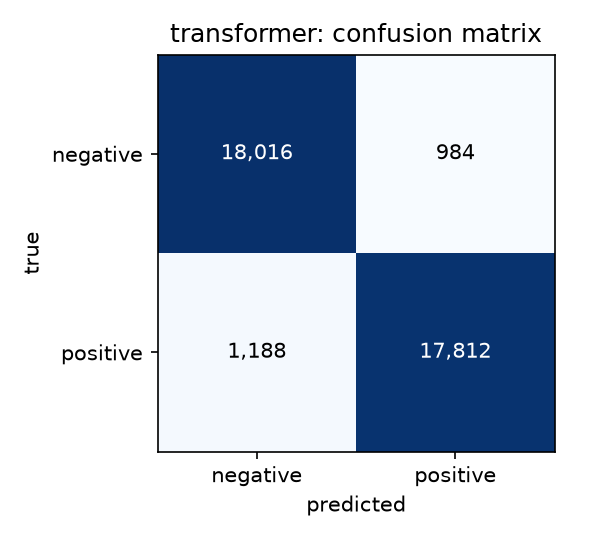

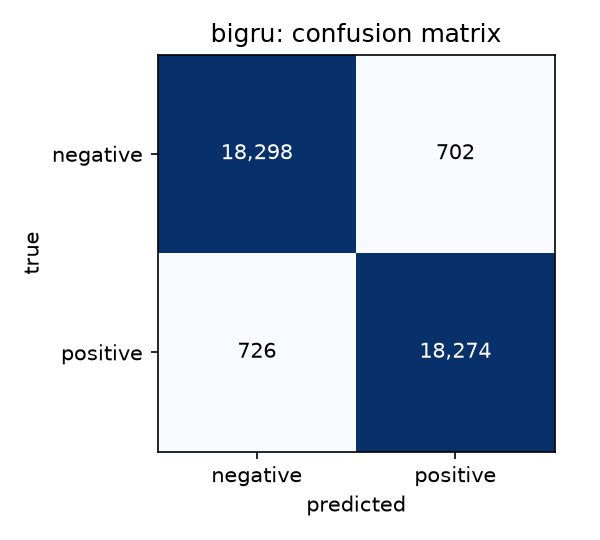

In [6]:
nh.show_test_metrics(cfg)

## 7. McNemar results and slice table

McNemar test against the baseline (b: baseline right and model wrong; c: baseline wrong and model right)


,model,mcnemar_b,mcnemar_c,mcnemar_p_exact,mcnemar_chi2,mcnemar_p_chi2
1,transformer,1134.0,491.0,1.231903e-58,253.639385,4.178722e-57
2,bigru,473.0,574.0,1.984145e-03,9.551098,1.998298e-03


,model,slice,n,macro-F1,error rate
0,ngram_bag,short,9122,0.9550,0.0432
1,ngram_bag,medium,21412,0.9601,0.0399
2,ngram_bag,long,7466,0.9600,0.0375
3,ngram_bag,has_negation,27859,0.9574,0.0411
4,ngram_bag,has_contrast,21277,0.9545,0.0449
5,transformer,short,9122,0.9415,0.0562
6,transformer,medium,21412,0.9418,0.0582
7,transformer,long,7466,0.9409,0.0553
8,transformer,has_negation,27859,0.9362,0.0615
9,transformer,has_contrast,21277,0.9337,0.0655


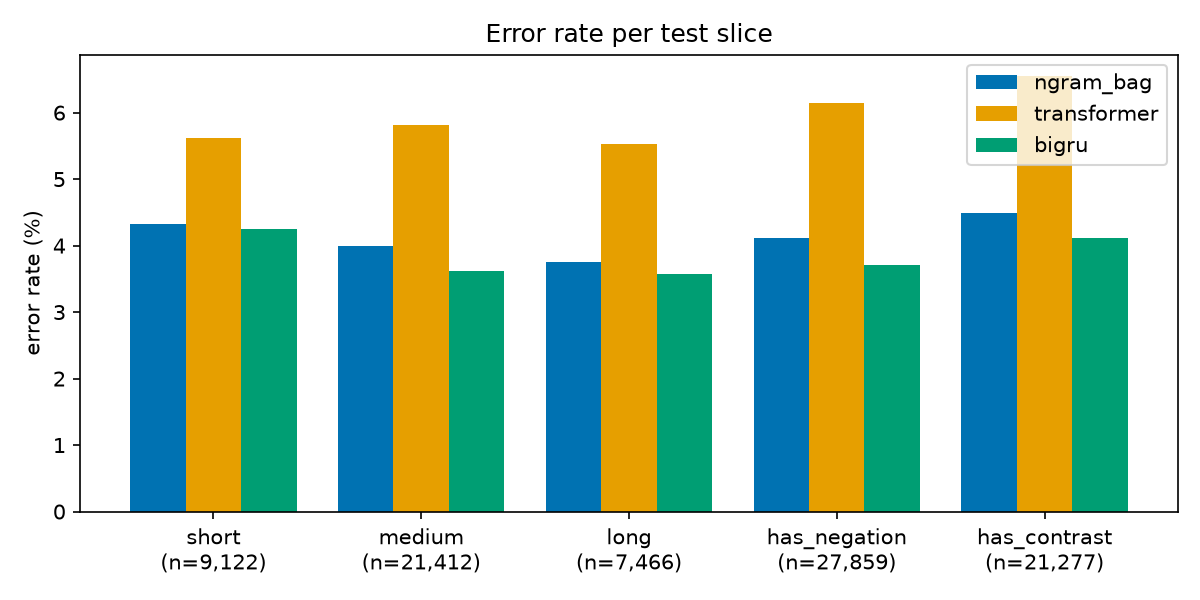

In [7]:
nh.show_mcnemar_and_slices(cfg)

## 8. Error review candidates

In [8]:
nh.show_error_review(cfg)

,rank,bucket,orig_index,true_label,predicted_label,positive_probability,raw_words,truncated_at_max_len,text
0,1,confident false positive,29330,0,1,0.999590,23,False,Wow love the place and everything is very clea...
1,2,confident false positive,3163,0,1,0.998112,17,False,What I love about Rubios' is that they always ...
2,3,confident false positive,20058,0,1,0.997892,10,False,Meat and two place. Pretty decent food. Great ...
3,4,confident false positive,12480,0,1,0.997161,28,False,my husband had an omelette that was good. i ha...
4,5,confident false positive,3465,0,1,0.996103,62,False,Wally world a necessary evil. it has low pric...
5,6,confident false negative,22807,1,0,0.000685,96,False,EDIT: They really did change the service up si...
6,7,confident false negative,30366,1,0,0.001413,178,False,We have eaten at the restaurant several times ...
7,8,confident false negative,26683,1,0,0.001833,27,False,"I've just been forced to concede that, despite..."
8,9,confident false negative,32275,1,0,0.003341,74,False,"As much as I enjoyed the food, it was just ext..."
9,10,confident false negative,30793,1,0,0.003657,98,False,This place is so much better since they change...


## 9. Hardware disclosure and reproducibility

In [9]:
nh.show_hardware(cfg)

torch 2.14.1+cu126, numpy 2.5.3, pandas 2.3.3, Python 3.12.10
platform: Windows 11
device: NVIDIA GeForce RTX 4090   CUDA available: True
seed: 42
config local.yaml sha256: fd2eee86b49a
config gpu.yaml sha256: 81585bfd576d
ngram_bag: trained on NVIDIA GeForce RTX 4090 with torch 2.14.1+cu126
transformer: trained on NVIDIA GeForce RTX 4090 with torch 2.14.1+cu126
bigru: trained on NVIDIA GeForce RTX 4090 with torch 2.14.1+cu126
